# The Survey object

Most of `airbornegeo`'s functions take a dataframe plus the names of the columns they need (`line_column`, `distance_column`, `time_column`, ...), which quickly gets repetitive. The `airbornegeo.Survey` class stores the dataframe together with those column names, a coordinate reference system, free-form metadata, and the survey's intersection table, and exposes most package functions as methods which fill the column names in for you.

Two kinds of methods:

- Methods which add or alter a few columns (e.g. `along_track_distance`, `filter_line`, the crossover pipeline) operate **in place** on `survey.data` and return the survey itself, so calls can be chained.
- Methods which replace the whole dataframe (`block_reduce`, `resample`, `resample_as`) return a **new** `Survey`, leaving the original untouched.

Summary statistics (bounding region, line counts, line lengths, spacings, and orientations) are computed lazily the first time you access them and cached afterwards.

The functional API is unchanged — every method simply wraps the function of the same name.

In [1]:
%load_ext autoreload
%autoreload 2

import logging

import numpy as np
import pandas as pd

import airbornegeo

# setup logging to get some additional info from the airbornegeo functions
logging.getLogger("airbornegeo").setLevel("INFO")
logging.basicConfig()

## Load data

This is a subset of the BAS AGAP aeromagnetic survey over Antarctica's Gamburtsev Subglacial Mountains, already processed and block-reduced (see the notebooks `AGAP_magnetic_survey` and `processing_AGAP_magnetics`). We mark the ~E-W survey lines with `line_type=0` and the ~N-S tie lines with `line_type=1`.

In [2]:
df = pd.read_csv("data/AGAP_magnetic_survey_processed_blocked.csv")
df = df[["easting", "northing", "height", "line", "unixtime", "mag"]]
df = df.dropna(subset="mag")

# for speed, limit the number of lines
df = df[~df.line.between(133, 142)]
df = df[~df.line.between(168, 176)]
df = df[(df.line.isin(df.line.unique()[::2])) | (df.line >= 143)]

# define survey lines (0) vs tie lines (1)
df["line_type"] = np.where(df.line >= 142, 1, 0)

df.head()

,easting,northing,height,line,unixtime,mag,line_type
0,621152.853769,159064.167598,4112.55,1,1.229500e+09,-34.245,0
1,621367.339673,159092.051982,4119.45,1,1.229500e+09,-37.740,0
2,621580.287957,159122.206492,4124.15,1,1.229500e+09,-40.975,0
3,621766.100699,159150.747140,4127.50,1,1.229500e+09,-43.430,0
4,621924.954435,159176.326498,4131.00,1,1.229500e+09,-45.300,0


## Create a Survey

We pass the dataframe once, along with the names of its structural columns, the coordinate reference system, and any metadata we want to keep with it. Only the projected coordinates default to a name (`easting`/`northing`, which the rest of the package requires); every other column must be named explicitly, since naming conventions vary too much between surveys to guess. Name them once here and every method will use them — a method needing a binding you did not set raises a `ValueError` telling you which one.

The `repr` shows the column bindings and which statistics have been computed so far — none yet, since they are lazy.

In [3]:
survey = airbornegeo.Survey(
    df,
    line_column="line",
    line_type_column="line_type",
    distance_column="distance_along_line",
    time_column="unixtime",
    height_column="height",
    crs="EPSG:3031",
    metadata={"survey": "AGAP aeromagnetics", "source": "BAS"},
)
survey

line,line
line_type,line_type
distance,distance_along_line
time,unixtime
height,height
latitude,not set
longitude,not set
crs,EPSG:3031
survey,AGAP aeromagnetics
source,BAS
region,not computed


## Plotting

The `plot()` method plots a simple overview map of the survey data.

<Axes: title={'center': 'Survey: AGAP aeromagnetics'}, xlabel='easting', ylabel='northing'>

/home/mdtanker/airbornegeo/.pixi/envs/docs/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


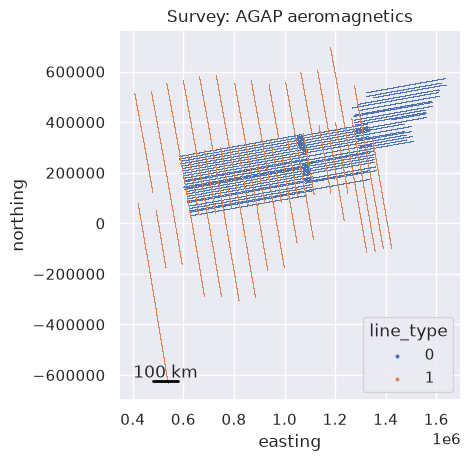

In [4]:
survey.plot(
    color_by="line_type",
    categorical=True,
    label_categories=True,
)

<Axes: title={'center': 'Survey: AGAP aeromagnetics'}, xlabel='easting', ylabel='northing'>

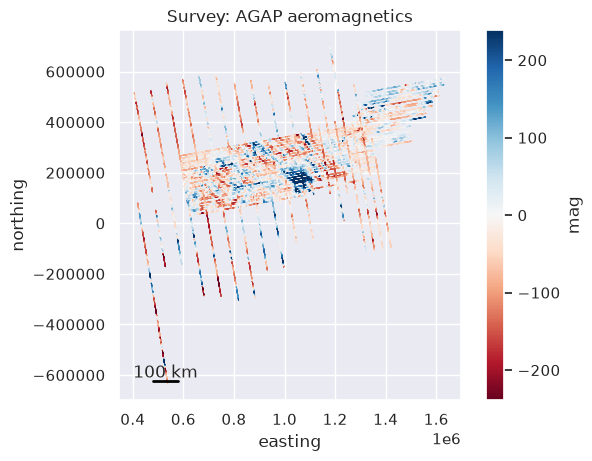

In [5]:
survey.plot(color_by="mag")

## Summary statistics

Each statistic is computed on first access and cached. Accessing them again is free, and the cache is cleared automatically whenever a method changes the survey's geometry (e.g. re-splitting lines or block-reducing).

In [6]:
survey.region

(405984.1809454474, 1636623.976977538, -632145.6203212709, 696582.6964278754)

In [7]:
survey.line_counts

{'total': 121, 'flight': 66, 'tie': 55}

Line spacings are estimated per line type with `airbornegeo.median_line_spacing`, and line orientations are compass azimuths (degrees clockwise from north, in the axial 0–180° range) of each line's minimum rotated bounding box.

In [8]:
survey.median_line_spacings

{'flight': 9729.398917801933, 'tie': 33189.404584862554}

In [9]:
survey.mean_line_azimuths

{'flight': 79.95350457799643, 'tie': 169.98710022379905}

`describe()` computes everything at once and returns a formatted summary.

In [10]:
print(survey.describe())

airbornegeo.Survey (199,181 rows x 7 cols)
  crs: EPSG:3031
  metadata: {'survey': 'AGAP aeromagnetics', 'source': 'BAS'}
  region (W, E, S, N): 405,984.2, 1,636,624.0, -632,145.6, 696,582.7
  line counts: total: 121, flight: 66, tie: 55
  total length: 39,902,272.0
  median line lengths: flight: 314,764.2, tie: 254,021.9
  mean line azimuths: flight: 80.0, tie: 170.0
  median line spacings: flight: 9,729.4, tie: 33,189.4


In [11]:
survey

line,line
line_type,line_type
distance,distance_along_line
time,unixtime
height,height
latitude,not set
longitude,not set
crs,EPSG:3031
survey,AGAP aeromagnetics
source,BAS
region,"405,984.2, 1,636,624.0, -632,145.6, 696,582.7"


## Chained processing

Methods which add columns mutate `survey.data` in place and return the survey, so processing steps chain naturally. Here we compute the distance along each line (written to the survey's `distance_column`) and low-pass filter the magnetic data along each line (written to `mag_filtered` by default).

In [12]:
survey.along_track_distance().filter_line(
    data_column="mag",
    filter_width=5e3,
)

survey.data[["line", "distance_along_line", "mag", "mag_filtered"]].head()

Segments:   0%|          | 0/121 [00:00<?, ?it/s]

Segments:   0%|          | 0/121 [00:00<?, ?it/s]

,line,distance_along_line,mag,mag_filtered
0,1,0.000000,-34.245,-43.331276
1,1,216.290873,-37.740,-43.601245
2,1,431.363573,-40.975,-44.356346
3,1,619.355444,-43.430,-45.353443
4,1,780.255453,-45.300,-46.457980


## Frame-replacing methods return a new Survey

`block_reduce`, `resample` and `resample_as` produce an entirely new dataframe, so instead of overwriting the survey they return a new `Survey` carrying over the column bindings, CRS and metadata — the original survey is retained.

In [13]:
blocked = survey.block_reduce(np.median, spacing=1e3)

print(f"original: {len(survey.data)} rows, blocked: {len(blocked.data)} rows")
blocked

Block-reducing segments:   0%|          | 0/121 [00:00<?, ?it/s]

original: 199181 rows, blocked: 39914 rows


line,line
line_type,line_type
distance,distance_along_line
time,unixtime
height,height
latitude,not set
longitude,not set
crs,EPSG:3031
survey,AGAP aeromagnetics
source,BAS
region,not computed


## Crossovers and levelling

The crossover pipeline stores the intersection table on the survey as `survey.intersections` and updates it, together with `survey.data`, as each chained step runs. Here we find the intersections between the survey lines and the tie lines (the `groups` method, using the `line_type` column), add them to the dataframe, interpolate the magnetic data onto them, and calculate the crossover errors.

(The `network` method finds intersections between *all* line pairs instead; note that pairs of lines crossing more than once must be deduplicated before the rest of the pipeline — see the crossovers notebooks for details.)

In [14]:
survey.create_intersection_table(
    method="groups",
    buffer_dist=500,
    cutoff_dist=400,
)
survey.intersections.head()

Line pairs:   0%|          | 0/3630 [00:00<?, ?it/s]

INFO:airbornegeo:found 669 intersections


INFO:airbornegeo:removed 3 intersection point(s) with a max distance greater than 0 km


,line1,line2,line1_along_dist,line2_along_dist,is_buffered,is_proximity,geometry,easting,northing,max_dist
0,1,143,545683.269511,137763.647746,False,False,POINT (1158153 254083),1158153.0,254083.0,73.980331
1,1,144,578867.489410,131264.857865,False,False,POINT (1190820 259865),1190820.0,259865.0,91.228123
2,1,145,612096.925761,146939.686838,False,False,POINT (1223524 265689),1223524.0,265689.0,77.978287
3,1,146,645286.779258,135889.427157,False,False,POINT (1256193 271497),1256193.0,271497.0,62.334186
4,1,147,678513.585282,154819.157039,False,False,POINT (1288902 277249),1288902.0,277249.0,99.009111


In [15]:
survey.add_intersections().interpolate_intersections(
    to_interp="mag"
).calculate_crossover_errors(data_col="mag")

survey.intersections.crossover_error_0.describe()

Interpolating segments:   0%|          | 0/121 [00:00<?, ?it/s]

count    664.000000
mean       7.640998
std       43.030551
min      -97.282149
25%      -27.513072
50%        5.989165
75%       40.616310
max      160.057662
Name: crossover_error_0, dtype: float64

Now we can level the survey using those crossover errors. The network levelling method updates both `survey.data` (adding the `mag_levelled` column) and `survey.intersections` (appending a new `crossover_error_N` column per iteration).

  0%|          | 0/5 [00:00<?, ?it/s]

Levelling terminated after 5 iterations with RMS of levelling correction of 6.79 because maximum number of iterations (5) reached.


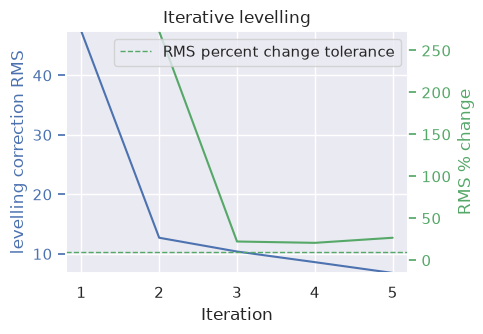

line,line
line_type,line_type
distance,distance_along_line
time,unixtime
height,height
latitude,not set
longitude,not set
crs,EPSG:3031
survey,AGAP aeromagnetics
source,BAS
region,not computed


In [16]:
survey.crossover_network_levelling(
    data_col="mag",
    levelled_col="mag_levelled",
    degree=1,
    max_iterations=5,
)

In [17]:
error_cols = [
    c for c in survey.intersections.columns if c.startswith("crossover_error_")
]
rms_before = airbornegeo.rmse(survey.intersections[error_cols[0]])
rms_after = airbornegeo.rmse(survey.intersections[error_cols[-1]])
print(f"crossover error RMS: {rms_before:.2f} -> {rms_after:.2f} nT")

crossover error RMS: 43.67 -> 13.42 nT


The functional equivalent of this whole notebook would have passed `line_column`, `distance_column` and the intersection table around at every step — with the `Survey` object they are stored once and injected for you, while `airbornegeo`'s functions remain available for anything not wrapped as a method (e.g. the Eötvös corrections and plotting utilities).

## Saving and reloading a Survey

`Survey` has two built-in ways to save and reload its full state — the data, the intersection table (if any), the CRS, the metadata, and the column-name bindings:

- **`to_parquet`/`from_parquet`** (recommended): the data and intersections are saved as Parquet files, plus a small JSON sidecar for the CRS/metadata/bindings. Parquet preserves dtypes exactly and is fast and compact, so prefer it unless you need a plain-text format.
- **`to_csv`/`from_csv`**: the same layout, but with CSV data files instead. Maximally portable and human-readable, at the cost of dtype fidelity (e.g. integer columns come back as floats) and file size.

Either way, the main data file is a plain Parquet/CSV file with no `airbornegeo`-specific encoding — anyone can read `<path>.parquet`/`<path>.csv` with bare `pandas`, no `airbornegeo` import required.

In [ ]:
import tempfile
from pathlib import Path

# replace this with your real local path you want to use
example_path = Path(tempfile.mkdtemp()) / "agap_survey"

# save the survey to the set path
survey.to_parquet(example_path)

# show the 3 file which were created
sorted(p.name for p in example_path.parent.iterdir())

['agap_survey.json',
 'agap_survey.parquet',
 'agap_survey_intersections.parquet']

In [19]:
reloaded = airbornegeo.Survey.from_parquet(example_path)
reloaded

line,line
line_type,line_type
distance,distance_along_line
time,unixtime
height,height
latitude,not set
longitude,not set
crs,EPSG:3031
survey,AGAP aeromagnetics
source,BAS
region,not computed


The data file needs nothing but `pandas` to read — no `airbornegeo` import required:

In [20]:
import pandas as pd

pd.read_parquet(example_path.with_suffix(".parquet")).head()

,easting,northing,height,line,unixtime,mag,line_type,distance_along_line,mag_filtered,is_intersection,intersecting_line,mag_interpolation_type,mag_levelled
0,621152.853769,159064.167598,4112.55,1,1.229500e+09,-34.245,0.0,0.000000,-43.331276,False,NaN,none,-25.597772
1,621367.339673,159092.051982,4119.45,1,1.229500e+09,-37.740,0.0,216.290873,-43.601245,False,NaN,none,-29.097845
2,621580.287957,159122.206492,4124.15,1,1.229500e+09,-40.975,0.0,431.363573,-44.356346,False,NaN,none,-32.337889
3,621766.100699,159150.747140,4127.50,1,1.229500e+09,-43.430,0.0,619.355444,-45.353443,False,NaN,none,-34.797299
4,621924.954435,159176.326498,4131.00,1,1.229500e+09,-45.300,0.0,780.255453,-46.457980,False,NaN,none,-36.671072
